In [1]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.models.black_scholes import BlackScholes
from src.models.heston import Heston
from src.models.merton_jump import MertonJumpDiffusion
from src.models.bates import Bates
from src.engine.monte_carlo import generate_gbm_paths, price_european_mc

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

In [2]:
S0 = 100
K = 100
T = 1.0
r = 0.05

n_paths = 50000
n_steps = 252


call_bs = BlackScholes(S0, K, T, r, 0.20).price('call')
print(f"Black-Scholes closed form: {call_bs:.4f}")

Black-Scholes closed form: 10.4506


In [3]:
paths_gbm = generate_gbm_paths(S0, r, 0.20, T, n_steps, n_paths, seed=42)
price_mc_bs, std_bs = price_european_mc(paths_gbm, K, r, T, 'call')

print(f"Black-Scholes MC: {price_mc_bs:.4f} +/- {1.96 * std_bs:.4f}")
print(f"Error: {abs(price_mc_bs - call_bs):.4f}")

Black-Scholes MC: 10.4526 +/- 0.1294
Error: 0.0020


In [4]:
v0 = 0.04
kappa = 2.0
theta = 0.04
sigma_v = 0.3
rho = -0.7

heston = Heston(S0, v0, kappa, theta, sigma_v, rho)
paths_heston, _ = heston.generate_paths(T, n_steps, n_paths, r, seed=42)
price_heston, std_heston = price_european_mc(paths_heston, K, r, T, 'call')

print(f"Heston: {price_heston:.4f} +/- {1.96 * std_heston:.4f}")
print(f"Diff from BS: {price_heston - call_bs:.4f}")

Heston: 10.4500 +/- 0.1079
Diff from BS: -0.0006


In [5]:
sigma = 0.20
lambda_jump = 0.5
mu_j = -0.05
sigma_j = 0.15

merton = MertonJumpDiffusion(S0, r, sigma, lambda_jump, mu_j, sigma_j)
paths_merton = merton.generate_paths(T, n_steps, n_paths, seed=42)
price_merton, std_merton = price_european_mc(paths_merton, K, r, T, 'call')

print(f"Merton: {price_merton:.4f} +/- {1.96 * std_merton:.4f}")
print(f"Diff from BS: {price_merton - call_bs:.4f}")

Merton: 11.4408 +/- 0.1454
Diff from BS: 0.9902


In [6]:
bates = Bates(S0, v0, kappa, theta, sigma_v, rho, lambda_jump, mu_j, sigma_j)
paths_bates, _ = bates.generate_paths(T, n_steps, n_paths, r, seed=42)
price_bates, std_bates = price_european_mc(paths_bates, K, r, T, 'call')

print(f"Bates: {price_bates:.4f} +/- {1.96 * std_bates:.4f}")
print(f"Diff from BS: {price_bates - call_bs:.4f}")

Bates: 11.4412 +/- 0.1274
Diff from BS: 0.9906


In [7]:
print("\n" + "="*60)
print("SUMMARY: European Call (S0=100, K=100, T=1y, r=5%)")
print("="*60)

print(f"\n{'Model':<20} {'Price':<12} {'95% CI':<18} {'Diff from BS':<15}")
print("-"*65)

print(f"{'Black-Scholes':<20} {call_bs:<12.4f} {'-':<18} {'-':<15}")
print(f"{'Black-Scholes (MC)':<20} {price_mc_bs:<12.4f} {'±' + str(round(1.96*std_bs,4)):<18} {price_mc_bs - call_bs:<15.4f}")
print(f"{'Heston':<20} {price_heston:<12.4f} {'±' + str(round(1.96*std_heston,4)):<18} {price_heston - call_bs:<15.4f}")
print(f"{'Merton':<20} {price_merton:<12.4f} {'±' + str(round(1.96*std_merton,4)):<18} {price_merton - call_bs:<15.4f}")
print(f"{'Bates':<20} {price_bates:<12.4f} {'±' + str(round(1.96*std_bates,4)):<18} {price_bates - call_bs:<15.4f}")


SUMMARY: European Call (S0=100, K=100, T=1y, r=5%)

Model                Price        95% CI             Diff from BS   
-----------------------------------------------------------------
Black-Scholes        10.4506      -                  -              
Black-Scholes (MC)   10.4526      ±0.1294            0.0020         
Heston               10.4500      ±0.1079            -0.0006        
Merton               11.4408      ±0.1454            0.9902         
Bates                11.4412      ±0.1274            0.9906         


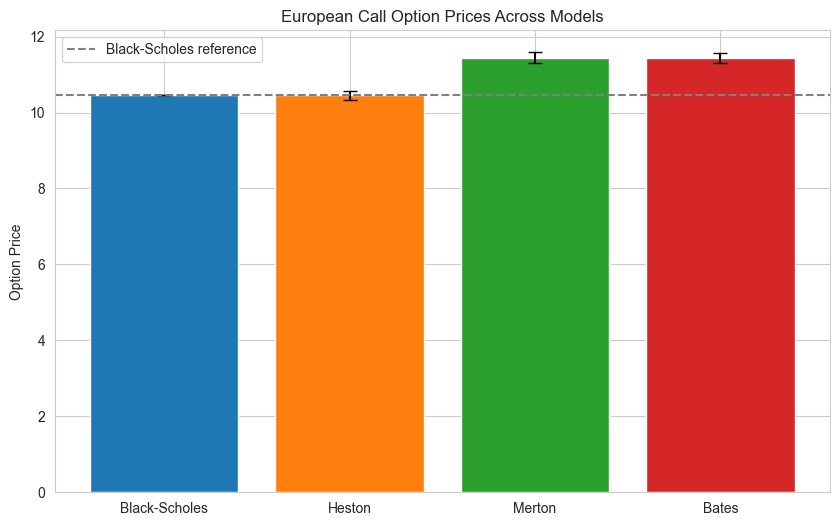

In [8]:
models = ['Black-Scholes', 'Heston', 'Merton', 'Bates']
prices = [call_bs, price_heston, price_merton, price_bates]
errors = [0, 1.96*std_heston, 1.96*std_merton, 1.96*std_bates]

plt.figure(figsize=(10, 6))
bars = plt.bar(models, prices, yerr=errors, capsize=5, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
plt.axhline(y=call_bs, color='gray', linestyle='--', label='Black-Scholes reference')
plt.ylabel('Option Price')
plt.title('European Call Option Prices Across Models')
plt.legend()
plt.show()

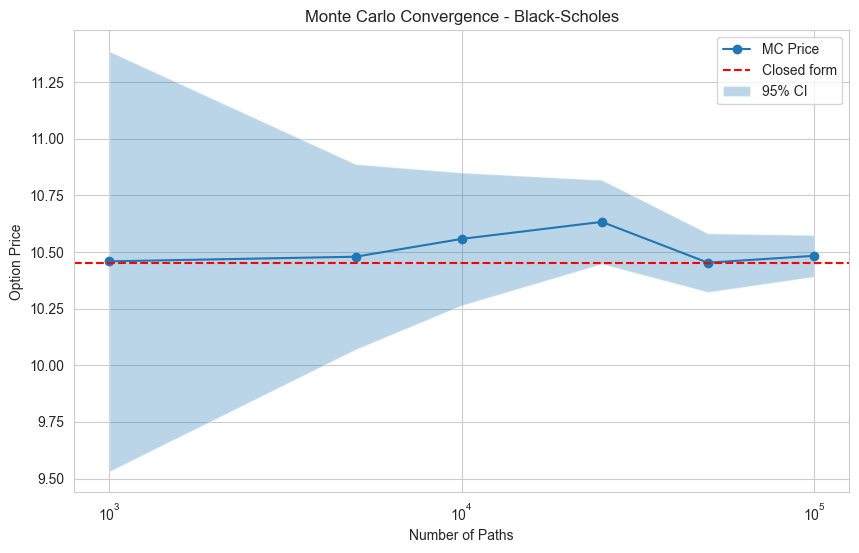

In [9]:
n_paths_list = [1000, 5000, 10000, 25000, 50000, 100000]
prices_conv = []
errors_conv = []

for n in n_paths_list:
    paths = generate_gbm_paths(S0, r, 0.20, T, n_steps, n, seed=42)
    p, e = price_european_mc(paths, K, r, T, 'call')
    prices_conv.append(p)
    errors_conv.append(e)

plt.figure(figsize=(10, 6))
plt.plot(n_paths_list, prices_conv, 'o-', label='MC Price')
plt.axhline(y=call_bs, color='r', linestyle='--', label='Closed form')
plt.fill_between(n_paths_list,
                 np.array(prices_conv) - 1.96*np.array(errors_conv),
                 np.array(prices_conv) + 1.96*np.array(errors_conv),
                 alpha=0.3, label='95% CI')
plt.xscale('log')
plt.xlabel('Number of Paths')
plt.ylabel('Option Price')
plt.title('Monte Carlo Convergence - Black-Scholes')
plt.legend()
plt.grid(True)
plt.show()

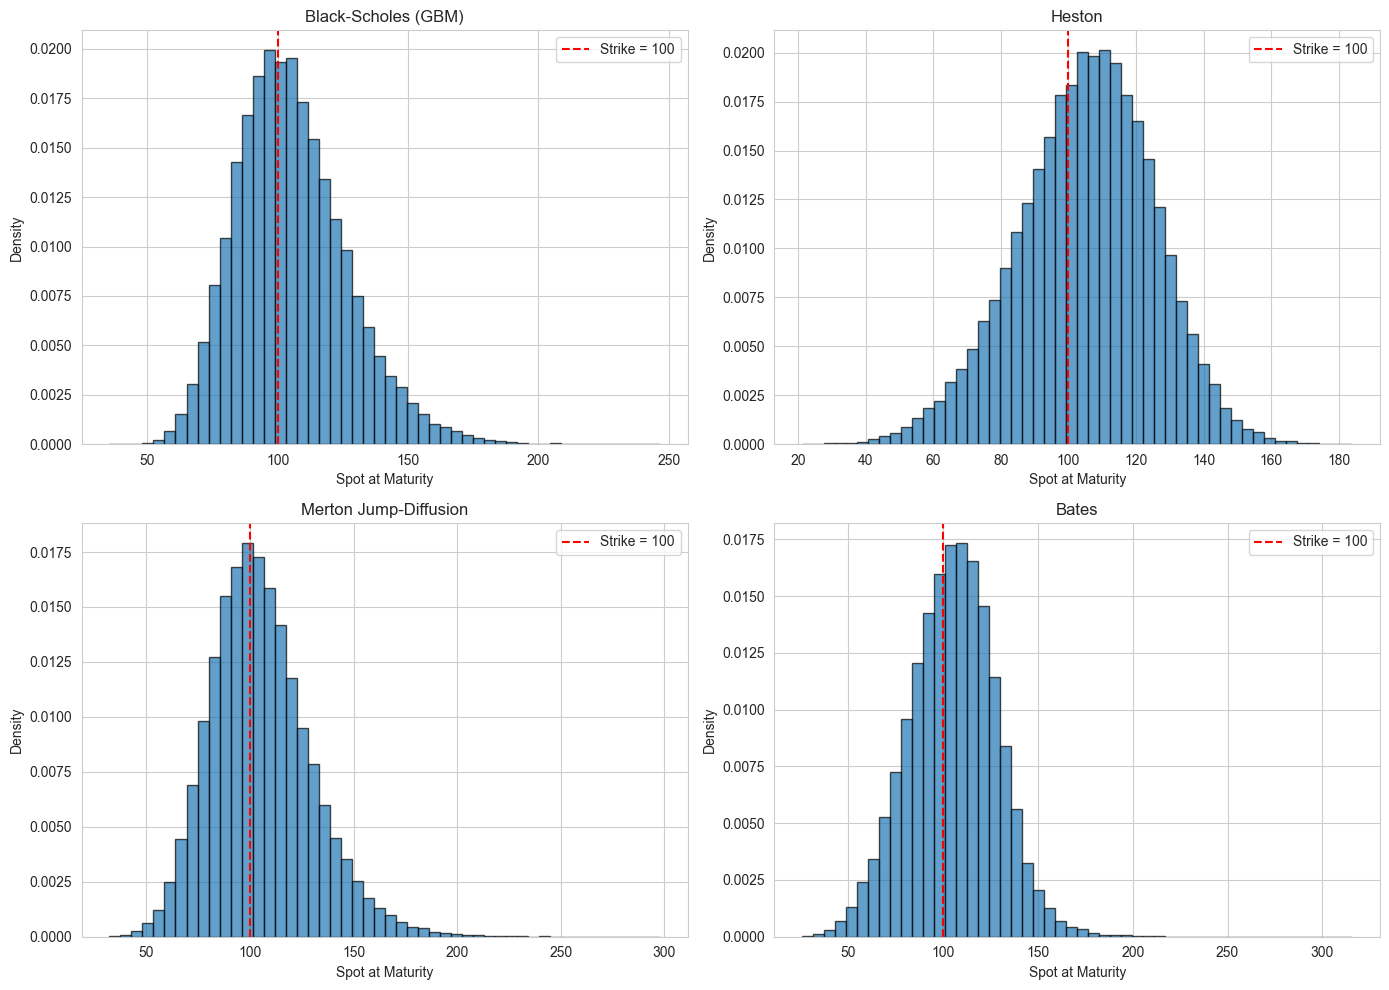

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

paths_list = [paths_gbm, paths_heston, paths_merton, paths_bates]
titles = ['Black-Scholes (GBM)', 'Heston', 'Merton Jump-Diffusion', 'Bates']

for ax, paths, title in zip(axes.flat, paths_list, titles):
    S_T = paths[:, -1]
    ax.hist(S_T, bins=50, density=True, alpha=0.7, edgecolor='black')
    ax.axvline(x=K, color='r', linestyle='--', label=f'Strike = {K}')
    ax.set_title(title)
    ax.set_xlabel('Spot at Maturity')
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.show()